# BSD35k Class-Selective Augmentation 실험 (per-class threshold)

목표: **BSD35k 증강으로 BSD10k baseline(H-Acc 79.24%)을 *넘는* 것.**

근거 분석: `deft논문기반_실험/bsd35k_filtering_replan_ko.md`

방법 — baseline(BSD35k 미추가)과 v4 증강(ge2/ge3/ge4)을 **같은 2192 holdout**에서 비교해,
**클래스마다 ge2/ge3/ge4 중 recall이 가장 좋아지는 threshold**를 고른다.
- 어떤 threshold에서도 baseline을 못 넘는 클래스(특히 fx-n, fx-m) → 35k **DROP**
- 넘는 클래스 → 그 클래스의 **최적 threshold**로만 35k 추가

| 전략 | 정의 |
|---|---|
| `baseline_b0` | BSD10k train80만 (이 노트북에서 직접 재학습) |
| `CP` | 클래스별 최적 threshold. best_delta > 0 이면 그 threshold로 ADD, 아니면 DROP |
| `CP1` | 보수형. best_delta >= +1.0(노이즈 마진) 이어야 ADD, 아니면 DROP |
| (참고) `v4_ge4`, `v4_all` | 기존 전역-threshold 결과를 비교표에 병기 |

**🔧 이번 버전 변경점 (60/20/20, pure val)**: BSD10k를 **train 60% / val 20% / test 20%**로 나눈다. **35k는 train fold에만** 섞고, **val·test는 순수 BSD10k**(35k 미포함). test는 기존과 동일한 고정 2192(20%). 구현: test 20% holdout 후, train_pool(80%)에 StratifiedKFold(4) → train 60% / val 20%. 결과는 새 폴더 `outputs/v4_35k_602020_pureval`에 저장.

**주의 1**: holdout·seed는 `SEED=1821` 고정(test 재현). 변경 금지.

**주의 2 (방법론)**: per-class threshold를 holdout(2192)으로 고르고 같은 holdout으로 평가하므로
약간 낙관적(선택 편향)이다. fx-n/fx-m DROP, m-m/fx-el/fx-o/fx-h ADD처럼 **모든 threshold에서 일관된**
신호는 안전하지만, fold std가 큰 클래스(ss-i, ss-n, fx-v 등)의 best threshold는 노이즈일 수 있다.
최종 판정은 §6 downstream 학습 결과로 한다.


## 0. Setup

In [17]:
from pathlib import Path
import json
import glob
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import StratifiedKFold

HERE = Path.cwd()
if not (HERE / 'baseline_confidnce_train').exists():
    ROOT = HERE.parent
else:
    ROOT = HERE

sys.path.insert(0, str(ROOT / 'baseline_confidnce_train'))
sys.path.insert(0, str(ROOT / 'dcase2026_task1_baseline'))

import confidence_baseline_common as cbc

# holdout 재현 위해 seed 고정 (test 2192 동일)
SEED = 1821
BASELINE_MODES = ('both',)
# 60/20/20: test 20%(고정) + train_pool 80%에 StratifiedKFold(4) -> train 60% / val 20%
VAL_FOLDS = 4
NUM_EPOCHS = 100
BATCH_SIZE = 64

# 변경점: 35k는 train fold에만 섞고 val/test는 순수 BSD10k. 새 폴더로 분리(기존 결과 보존).
OUTPUT_ROOT = ROOT / 'baseline_confidnce_train' / 'outputs' / 'v4_35k_602020_pureval'
PLOTS_DIR = OUTPUT_ROOT / 'plots'
DATASET_DIR = OUTPUT_ROOT / 'datasets'
for path in [OUTPUT_ROOT, PLOTS_DIR, DATASET_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# 기존 전역-threshold 실험 결과 폴더 (비교표 + per-class delta 근거)
PREV_AUG_ROOT = ROOT / 'baseline_confidnce_train' / 'outputs' / 'v4_35k_baseline_model'
BASELINE_PROXY_ROOT = ROOT / 'baseline_confidnce_train' / 'outputs' / '517_mlp_classification'

random.seed(SEED)
np.random.seed(SEED)
cbc.seed_everything(SEED)

print('ROOT:', ROOT)
print('OUTPUT_ROOT:', OUTPUT_ROOT)
print('device:', cbc.device_summary())

ROOT: c:\Users\solok\Desktop\Dcase baseline
OUTPUT_ROOT: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_602020_pureval
device: cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)


## 1. Fixed BSD10k split — test 20% 고정 + train_pool 80%

test 20%(2192)는 고정 holdout. train_pool 80%(8764)는 §5에서 StratifiedKFold(4)로 train 60% / val 20%로 나눈다 (val 순수 10k).

In [18]:
full_df, class_dict, top_class_dict = cbc.load_baseline_assets(ROOT)
train_pool, final_test, split_df = cbc.make_fixed_holdout(full_df, OUTPUT_ROOT, seed=SEED, test_size=0.2)

print('BSD10k full:', len(full_df))
print('BSD10k train_pool 80%:', len(train_pool))
print('BSD10k final_test 20%:', len(final_test))
print('classes in train_pool:', train_pool['class'].nunique())
display(split_df.head())

BSD10k full: 10956
BSD10k train_pool 80%: 8764
BSD10k final_test 20%: 2192
classes in train_pool: 23


,sound_id,class,class_idx,split
0,148475,is-k,6,train_pool
1,246968,is-w,5,train_pool
2,247907,is-s,4,train_pool
3,93909,is-p,3,train_pool
4,78499,ss-u,21,train_pool


## 2. Load BSD35k v4 predictions -> DCASE-compatible rows

`v4_35k_baseline모델.ipynb`의 `build_bsd35k_dcase_dataframe`와 동일.

In [19]:
BSD35K_V4_PATH = ROOT / 'outputs' / 'confidence_filter_v4' / 'predictions' / 'BSD35k-CS_filter_predictions_v4.csv'
assert BSD35K_V4_PATH.exists(), f'Missing file: {BSD35K_V4_PATH}'

def build_bsd35k_dcase_dataframe(v4_path: Path) -> pd.DataFrame:
    score_df = pd.read_csv(v4_path)
    score_df['sound_id'] = score_df['sound_id'].astype(str)
    top_col = 'class_top' if 'class_top' in score_df.columns else 'top_class'
    needed = ['sound_id', 'class', top_col, 'v4_filter_score', 'binary_mlp_prob', 'fiveclass_score', 'fiveclass_p45']
    missing = [c for c in needed if c not in score_df.columns]
    if missing:
        raise ValueError(f'Missing columns in BSD35k v4 file: {missing}')
    out = score_df[needed].copy().rename(columns={top_col: 'top_class'})
    out['index'] = out['sound_id'].astype(str)
    out['class'] = out['class'].astype(str)
    out['top_class'] = out['top_class'].astype(str)
    out['class_idx'] = out['class'].map(class_dict)
    out['top_class_idx'] = out['top_class'].map(top_class_dict)
    bsd35k_audio_dir = ROOT / 'data' / 'features' / 'BSD35k_clap_audio_embeddings'
    bsd35k_text_dir = ROOT / 'data' / 'features' / 'BSD35k-CS_clap_text_embeddings'
    out['audio_emb_filepath'] = out['index'].map(lambda sid: str(bsd35k_audio_dir / f'{sid}.npy'))
    out['text_emb_filepath'] = out['index'].map(lambda sid: str(bsd35k_text_dir / f'{sid}.npy'))
    out['predicted_confidence_score'] = 1.0 + 4.0 * out['v4_filter_score'].astype(float)
    before = len(out)
    bsd10k_ids = set(full_df['index'].astype(str))
    out = out[~out['index'].isin(bsd10k_ids)].copy()
    out = out[out['class_idx'].notna() & out['top_class_idx'].notna()].copy()
    out = out[out['audio_emb_filepath'].map(lambda p: Path(p).exists())].copy()
    out = out[out['text_emb_filepath'].map(lambda p: Path(p).exists())].copy()
    out['class_idx'] = out['class_idx'].astype(int)
    out['top_class_idx'] = out['top_class_idx'].astype(int)
    out = out.reset_index(drop=True)
    print(f'BSD35k rows before filtering: {before:,}  ->  usable: {len(out):,}  | classes: {out["class"].nunique()}')
    return out

bsd35k_all = build_bsd35k_dcase_dataframe(BSD35K_V4_PATH)
display(bsd35k_all.head(3))

BSD35k rows before filtering: 31,464  ->  usable: 31,464  | classes: 23


,sound_id,class,top_class,v4_filter_score,binary_mlp_prob,fiveclass_score,fiveclass_p45,index,class_idx,top_class_idx,audio_emb_filepath,text_emb_filepath,predicted_confidence_score
0,796088,fx-h,fx,0.851735,0.745651,3.783054,0.784744,796088,14,3,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,4.406941
1,796133,fx-n,fx,0.384630,0.501452,3.406448,0.441924,796133,16,3,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,2.538520
2,796149,ss-n,ss,0.327088,0.471124,3.375044,0.448676,796149,19,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,2.308352


## 3. per-class threshold 분석 (ge2/ge3/ge4 전부) -> class policy

각 클래스의 recall을 baseline과 ge2/ge3/ge4에서 비교한다.
- baseline = `517_mlp_classification/pred_ge_2` (retained 100% = BSD10k-only, 같은 2192 holdout)
- 증강 = `v4_35k_baseline_model/v4_ge2`, `v4_ge3`, `v4_ge4`

클래스별로 **delta(=recall_geX - recall_base)가 가장 큰 threshold**를 고른다.
- `best_delta > 0` 인 threshold가 있으면 그 threshold로 ADD
- 모든 threshold에서 `<= 0` 이면 DROP

(`pcs = predicted_confidence_score = 1 + 4*v4_filter_score`. ge2/ge3/ge4 = pcs>=2/3/4.)

In [20]:
def mean_diag(pattern):
    mats = []
    for f in sorted(glob.glob(pattern)):
        df = pd.read_csv(f, index_col=0)
        mats.append(pd.Series(np.diag(df.values), index=df.index))
    if not mats:
        raise FileNotFoundError(f'No confusion matrices: {pattern}')
    return pd.concat(mats, axis=1)

base_mats = mean_diag(str(BASELINE_PROXY_ROOT / 'pred_ge_2' / 'both' / 'fold_*' / 'evaluation' / 'confusion_matrix_normalized_true.csv'))
base_recall = base_mats.mean(axis=1) * 100

THRMAP = {'ge2': 2.0, 'ge3': 3.0, 'ge4': 4.0}
delta = pd.DataFrame({'baseline_recall': base_recall.round(2)})
delta['base_std'] = (base_mats.std(axis=1) * 100).round(2)
for lab in ['ge2', 'ge3', 'ge4']:
    rec = mean_diag(str(PREV_AUG_ROOT / f'v4_{lab}' / 'both' / 'fold_*' / 'evaluation' / 'confusion_matrix_normalized_true.csv')).mean(axis=1) * 100
    delta[f'd_{lab}'] = (rec - base_recall).round(2)
delta.index.name = 'class'

def pick(row):
    cands = {lab: row[f'd_{lab}'] for lab in ['ge2', 'ge3', 'ge4']}
    best = max(cands, key=cands.get)
    return pd.Series([best, round(cands[best], 2)])
delta[['best_thr', 'best_delta']] = delta.apply(pick, axis=1)

# 정책: CP = best_delta>0 이면 ADD@best_thr, 아니면 DROP / CP1 = best_delta>=1.0 이어야 ADD
def policy(best_delta, margin):
    return best_delta > margin
delta['CP_add'] = delta['best_delta'] > 0.0
delta['CP1_add'] = delta['best_delta'] >= 1.0
delta['n_35k_total'] = delta.index.map(bsd35k_all.groupby('class').size()).fillna(0).astype(int)

delta = delta.sort_values('best_delta')
display(delta[['baseline_recall', 'base_std', 'd_ge2', 'd_ge3', 'd_ge4', 'best_thr', 'best_delta', 'CP_add', 'CP1_add', 'n_35k_total']])
print('CP  DROP classes :', delta[~delta['CP_add']].index.tolist())
print('CP1 DROP classes :', delta[~delta['CP1_add']].index.tolist())

,baseline_recall,base_std,d_ge2,d_ge3,d_ge4,best_thr,best_delta,CP_add,CP1_add,n_35k_total
class,,,,,,,,,,
fx-n,92.27,3.61,-27.88,-14.39,-10.91,ge4,-10.91,False,False,659
fx-m,77.86,2.99,-12.14,-10.00,-5.00,ge4,-5.00,False,False,1542
m-sp,88.32,2.25,-4.96,-4.38,-2.92,ge4,-2.92,False,False,964
sp-p,81.11,5.61,-5.56,-5.83,-2.50,ge4,-2.50,False,False,69
m-si,81.69,5.48,-4.51,-3.80,-1.27,ge4,-1.27,False,False,1344
fx-a,43.53,12.02,-7.65,-9.41,-1.18,ge4,-1.18,False,False,730
is-p,88.69,1.78,-1.48,-1.80,-0.33,ge4,-0.33,False,False,2321
sp-c,45.14,12.02,-3.43,-1.71,-0.00,ge4,-0.00,False,False,50
is-k,92.78,3.85,0.00,-0.56,-0.28,ge2,0.00,False,False,43


CP  DROP classes : ['fx-n', 'fx-m', 'm-sp', 'sp-p', 'm-si', 'fx-a', 'is-p', 'sp-c', 'is-k']
CP1 DROP classes : ['fx-n', 'fx-m', 'm-sp', 'sp-p', 'm-si', 'fx-a', 'is-p', 'sp-c', 'is-k', 'is-w', 'sp-s']


## 4. build CP / CP1 addition sets (+ subset & analysis CSVs)

In [21]:
def build_subset(add_flag_col):
    parts = []
    for cls, row in delta.iterrows():
        if not row[add_flag_col]:
            continue
        thr = THRMAP[row['best_thr']]
        parts.append(bsd35k_all[(bsd35k_all['class'] == cls) & (bsd35k_all['predicted_confidence_score'] >= thr)])
    return pd.concat(parts, ignore_index=True).reset_index(drop=True) if parts else bsd35k_all.iloc[0:0]

CP = build_subset('CP_add')
CP1 = build_subset('CP1_add')

keepcols = ['sound_id', 'class', 'top_class', 'v4_filter_score', 'binary_mlp_prob', 'fiveclass_score', 'predicted_confidence_score']
CP[keepcols].assign(strategy='CP').to_csv(OUTPUT_ROOT / 'bsd35k_subset_CP_perclass.csv', index=False)
CP1[keepcols].assign(strategy='CP1').to_csv(OUTPUT_ROOT / 'bsd35k_subset_CP1_perclass.csv', index=False)

ret = delta.copy()
for name, sub in [('CP', CP), ('CP1', CP1)]:
    cnt = sub.groupby('class').size()
    ret[f'{name}_retained'] = ret.index.map(cnt).fillna(0).astype(int)
    ret[f'{name}_chosen_thr'] = np.where(ret[f'{name}_retained'] > 0, ret['best_thr'], 'DROP')
ret.to_csv(OUTPUT_ROOT / 'per_class_threshold_analysis.csv')

print(f'CP : {len(CP):,} added  ({len(CP)/len(bsd35k_all)*100:.1f}%)  classes={CP["class"].nunique()}')
print(f'CP1: {len(CP1):,} added  ({len(CP1)/len(bsd35k_all)*100:.1f}%)  classes={CP1["class"].nunique()}')
display(ret[['best_thr', 'best_delta', 'n_35k_total', 'CP_retained', 'CP_chosen_thr', 'CP1_retained']].sort_values('best_delta'))

CP : 10,121 added  (32.2%)  classes=14
CP1: 9,335 added  (29.7%)  classes=12


,best_thr,best_delta,n_35k_total,CP_retained,CP_chosen_thr,CP1_retained
class,,,,,,
fx-n,ge4,-10.91,659,0,DROP,0
fx-m,ge4,-5.00,1542,0,DROP,0
m-sp,ge4,-2.92,964,0,DROP,0
sp-p,ge4,-2.50,69,0,DROP,0
m-si,ge4,-1.27,1344,0,DROP,0
fx-a,ge4,-1.18,730,0,DROP,0
is-p,ge4,-0.33,2321,0,DROP,0
sp-c,ge4,-0.00,50,0,DROP,0
is-k,ge2,0.00,43,0,DROP,0


## 5. Train (baseline_b0 / CP / CP1) — 60/20/20, val·test 순수 10k

**train_pool(80% 순수 10k)에 StratifiedKFold(4)** → train 60% / val 20%. **35k는 train fold에만** 추가하고 val에는 넣지 않는다. test는 고정 final_test 2192(20% 순수 10k). 기존 run 있으면 자동 skip.

In [22]:
addition_sets = {
    'baseline_b0': bsd35k_all.iloc[0:0],   # BSD10k train만 (35k 미추가)
    'CP': CP,
    'CP1': CP1,
}

RUN_DATASET_LABELS = ['baseline_b0', 'CP', 'CP1']

def run_one_dataset(dataset_label, addition_df):
    """60/20/20: train(60% 10k + 35k) / val(20% 순수 10k) / test(20% 순수 10k, 고정).
    35k는 train fold에만 추가하고 val/test에는 절대 넣지 않는다."""
    rows = []
    dataset_dir = OUTPUT_ROOT / dataset_label
    dataset_dir.mkdir(parents=True, exist_ok=True)
    # KFold는 train_pool(순수 BSD10k 80%)에만 적용 -> train 60% / val 20%
    splitter = StratifiedKFold(n_splits=VAL_FOLDS, shuffle=True, random_state=SEED)
    splits = list(splitter.split(np.zeros(len(train_pool)), train_pool['class_idx']))
    for mode in BASELINE_MODES:
        for fold, (train_idx, val_idx) in enumerate(splits):
            run_dir = dataset_dir / mode / f'fold_{fold}'
            tr_10k = train_pool.iloc[train_idx].reset_index(drop=True)   # 60% 순수 10k
            va_df = train_pool.iloc[val_idx].reset_index(drop=True)      # 20% 순수 10k (35k 없음)
            if len(addition_df) > 0:
                tr_df = pd.concat([tr_10k, addition_df[train_pool.columns]], ignore_index=True).reset_index(drop=True)
            else:
                tr_df = tr_10k
            base_row = {
                'dataset_label': dataset_label, 'mode': mode, 'split': f'fold_{fold}',
                'train_samples': int(len(tr_df)), 'val_samples': int(len(va_df)),
                'final_test_samples': int(len(final_test)),
                'bsd10k_train_samples': int(len(tr_10k)),
                'added_bsd35k_samples': int(len(addition_df)),
                'output_dir': str(run_dir),
            }
            metrics_path = run_dir / 'evaluation' / 'results.txt'
            if metrics_path.exists():
                rows.append({**base_row, 'status': 'completed_existing', **cbc.read_metrics_file(metrics_path)})
                print('[skip] existing run:', run_dir)
                continue
            best_val_acc, metrics = cbc.train_and_evaluate_one(
                tr_df, va_df, final_test, class_dict, top_class_dict, run_dir,
                mode=mode, seed=SEED, batch_size=BATCH_SIZE, num_epochs=NUM_EPOCHS,
                lr=0.001, patience=5, early_stopping_factor=3,
            )
            rows.append({**base_row, 'status': 'ok', 'best_val_accuracy': float(best_val_acc), **metrics})
            pd.DataFrame(rows).to_csv(dataset_dir / 'summary_results_partial.csv', index=False)
    return rows

all_rows = []
for dataset_label in RUN_DATASET_LABELS:
    print('\n' + '=' * 90)
    print('Running dataset:', dataset_label)
    rows = run_one_dataset(dataset_label, addition_sets[dataset_label])
    all_rows.extend(rows)
    pd.DataFrame(all_rows).to_csv(OUTPUT_ROOT / 'summary_results.csv', index=False)

summary = pd.DataFrame(all_rows)
summary.to_csv(OUTPUT_ROOT / 'summary_results.csv', index=False)
display(summary)


Running dataset: baseline_b0

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_602020_pureval\baseline_b0\both\fold_0
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=6573, val=2191, final_test=2192
  batches: train=102, val=35, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 52.94%
  New best model saved
Epoch [2/100] - Val acc: 65.45%
  New best model saved
Epoch [3/100] - Val acc: 70.88%
  New best model saved
Epoch [4/100] - Val acc: 75.13%
  New best model saved
Epoch [5/100] - Val acc: 75.26%
  New best model saved
Epoch [6/100] - Val acc: 75.99%
  New best model saved
Epoch [7/100] - Val acc: 76.18%
  New best model saved
Epoch [8/100] - Val acc: 77.68%
  New best model saved
Epoch [9/100] - Val acc: 77.77%
  New best model saved
Epoch [10/100] - Val acc: 79.14%
  New best model saved
Epoch [11/100] - Val acc: 78.78%
Epoch [12/100] - Val acc: 78.50%
Epoch [13/100] - Val acc: 77.64%
Epoch [14/100] - Val acc: 7

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 79.52%
[BaseClassifier | Fold final_test] Top class accuracy: 89.01%
[BaseClassifier | Fold final_test] Macro accuracy: 71.56%
[BaseClassifier | Fold final_test] Macro top class accuracy: 83.57%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 77.56%
[BaseClassifier | Fold final_test] Hierarchical precision: 78.58%
[BaseClassifier | Fold final_test] Hierarchical recall: 76.06%
[BaseClassifier | Fold final_test] Hierarchical F1: 76.64%
  completed in 7.1 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_602020_pureval\baseline_b0\both\fold_1
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=6573, val=2191, final_test=2192
  batches: train=102, val=35, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 53.22%
  New best model saved
Epoch [2/100] - Val acc: 69.01%
  New best model saved
Epoch [3/100] - Val acc: 71.70%
  New best model saved
Epoch [4/100] - Val acc: 7

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 81.34%
[BaseClassifier | Fold final_test] Top class accuracy: 89.64%
[BaseClassifier | Fold final_test] Macro accuracy: 75.60%
[BaseClassifier | Fold final_test] Macro top class accuracy: 85.71%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 80.66%
[BaseClassifier | Fold final_test] Hierarchical precision: 81.25%
[BaseClassifier | Fold final_test] Hierarchical recall: 79.39%
[BaseClassifier | Fold final_test] Hierarchical F1: 79.97%
  completed in 9.0 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_602020_pureval\baseline_b0\both\fold_2
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=6573, val=2191, final_test=2192
  batches: train=102, val=35, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 54.72%
  New best model saved
Epoch [2/100] - Val acc: 66.36%
  New best model saved
Epoch [3/100] - Val acc: 72.57%
  New best model saved
Epoch [4/100] - Val acc: 7

...

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 77.51%
[BaseClassifier | Fold final_test] Top class accuracy: 86.82%
[BaseClassifier | Fold final_test] Macro accuracy: 69.99%
[BaseClassifier | Fold final_test] Macro top class accuracy: 81.29%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 75.64%
[BaseClassifier | Fold final_test] Hierarchical precision: 75.72%
[BaseClassifier | Fold final_test] Hierarchical recall: 74.23%
[BaseClassifier | Fold final_test] Hierarchical F1: 74.45%
  completed in 21.9 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_602020_pureval\CP1\both\fold_3
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=15908, val=2191, final_test=2192
  batches: train=248, val=35, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 52.67%
  New best model saved
Epoch [2/100] - Val acc: 70.24%
  New best model saved
Epoch [3/100] - Val acc: 71.66%
  New best model saved
Epoch [4/100] - Val acc: 73.89%


c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 79.01%
[BaseClassifier | Fold final_test] Top class accuracy: 87.41%
[BaseClassifier | Fold final_test] Macro accuracy: 72.70%
[BaseClassifier | Fold final_test] Macro top class accuracy: 83.06%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 77.88%
[BaseClassifier | Fold final_test] Hierarchical precision: 79.17%
[BaseClassifier | Fold final_test] Hierarchical recall: 76.58%
[BaseClassifier | Fold final_test] Hierarchical F1: 76.87%
  completed in 21.0 min


,dataset_label,mode,split,train_samples,val_samples,final_test_samples,bsd10k_train_samples,added_bsd35k_samples,output_dir,status,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1
0,baseline_b0,both,fold_0,6573,2191,2192,6573,0,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,79.141944,79.516423,89.005474,71.556050,83.565655,77.560852,78.578130,76.059652,76.644502
1,baseline_b0,both,fold_1,6573,2191,2192,6573,0,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,80.830671,81.341241,89.644161,75.597136,85.713576,80.655356,81.250738,79.390801,79.973146
2,baseline_b0,both,fold_2,6573,2191,2192,6573,0,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,79.461433,80.885036,88.868613,74.597257,84.388860,79.493059,79.924268,78.269108,78.780535
3,baseline_b0,both,fold_3,6573,2191,2192,6573,0,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,79.552716,79.562044,88.686131,74.275330,84.850600,79.562965,78.577610,78.241056,78.210580
4,CP,both,fold_0,16694,2191,2192,6573,10121,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,78.229119,77.235401,86.541971,71.082285,82.107204,76.594744,77.351007,75.216629,75.698394
5,CP,both,fold_1,16694,2191,2192,6573,10121,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,77.955272,78.467153,87.363139,71.736034,82.653696,77.194865,78.645470,75.830157,76.418094
6,CP,both,fold_2,16694,2191,2192,6573,10121,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,77.361935,76.596715,86.040146,70.063297,81.470437,75.766867,75.981840,74.340974,74.600476
7,CP,both,fold_3,16694,2191,2192,6573,10121,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,76.996805,77.645985,87.728102,73.190393,84.228346,78.709369,77.159671,77.329625,76.897450
8,CP1,both,fold_0,15908,2191,2192,6573,9335,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,77.407576,77.828467,86.861314,71.792329,81.935150,76.863740,78.609546,75.595887,76.146325
9,CP1,both,fold_1,15908,2191,2192,6573,9335,c:\Users\solok\Desktop\Dcase baseline\baseline...,ok,78.092195,78.239051,87.500000,72.212020,82.672829,77.442425,78.096546,76.134823,76.582610


## 6. 전략 비교표 (baseline_b0 / CP / CP1 + 기존 v4_ge4·v4_all)

성공 기준: **H-Acc > baseline_b0**

In [23]:
METRICS = ['accuracy', 'hierarchical_accuracy', 'hierarchical_f1', 'macro_accuracy', 'macro_top_accuracy', 'top_accuracy']

def mean_std(df):
    out = {}
    for m in METRICS:
        if m in df.columns:
            out[f'{m}_mean'] = round(float(df[m].mean()), 3)
            out[f'{m}_std'] = round(float(df[m].std()), 3)
    return out

rows = []
for lab, g in summary.groupby('dataset_label'):
    rows.append({'strategy': lab, 'added_bsd35k': int(g['added_bsd35k_samples'].iloc[0]), **mean_std(g)})

# 기존 전역-threshold 실험 병기 (있으면)
prev_path = PREV_AUG_ROOT / 'fold_metric_summary_mean_std.csv'
if prev_path.exists():
    prev = pd.read_csv(prev_path)
    for _, r in prev.iterrows():
        row = {'strategy': r['dataset_label'], 'added_bsd35k': '-'}
        for m in METRICS:
            if f'{m}_mean' in r:
                row[f'{m}_mean'] = round(float(r[f'{m}_mean']), 3)
                row[f'{m}_std'] = round(float(r[f'{m}_std']), 3)
        rows.append(row)

comp = pd.DataFrame(rows).sort_values('hierarchical_accuracy_mean', ascending=False).reset_index(drop=True)
comp.to_csv(OUTPUT_ROOT / 'aug_strategy_comparison.csv', index=False)
display(comp[['strategy', 'added_bsd35k', 'accuracy_mean', 'hierarchical_accuracy_mean', 'macro_accuracy_mean', 'top_accuracy_mean']])

if 'baseline_b0' in comp['strategy'].values:
    b0 = comp.loc[comp['strategy'] == 'baseline_b0', 'hierarchical_accuracy_mean'].iloc[0]
    print(f'\nbaseline_b0 H-Acc = {b0:.3f}')
    for lab in ['CP', 'CP1']:
        if lab in comp['strategy'].values:
            v = comp.loc[comp['strategy'] == lab, 'hierarchical_accuracy_mean'].iloc[0]
            verdict = 'BEATS baseline' if v > b0 else 'below baseline'
            print(f'{lab} H-Acc = {v:.3f}  ({v - b0:+.3f})  -> {verdict}')

,strategy,added_bsd35k,accuracy_mean,hierarchical_accuracy_mean,macro_accuracy_mean,top_accuracy_mean
0,baseline_b0,0,80.326,79.318,74.006,89.051
1,v4_ge4,-,79.279,78.803,73.451,88.339
2,v4_ge3,-,78.741,77.992,72.622,87.728
3,CP,10121,77.486,77.066,71.518,86.918
4,CP1,9335,78.148,76.956,71.673,87.146
5,v4_ge2,-,77.381,76.922,71.130,86.999
6,v4_all,-,77.354,76.239,70.371,87.016



baseline_b0 H-Acc = 79.318
CP H-Acc = 77.066  (-2.252)  -> below baseline
CP1 H-Acc = 76.956  (-2.362)  -> below baseline


C:\Users\solok\AppData\Local\Temp\ipykernel_36336\1441201262.py:37: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\solok\AppData\Local\Temp\ipykernel_36336\1441201262.py:37: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\solok\AppData\Local\Temp\ipykernel_36336\1441201262.py:38: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.savefig(PLOTS_DIR / 'cm_foldavg_3models.png', dpi=180, bbox_inches='tight')
C:\Users\solok\AppData\Local\Temp\ipykernel_36336\1441201262.py:38: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.savefig(PLOTS_DIR / 'cm_foldavg_3models.png', dpi=180, bbox_inches='tight')
c:\Users\solok\Desktop\Dcase baseline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaV

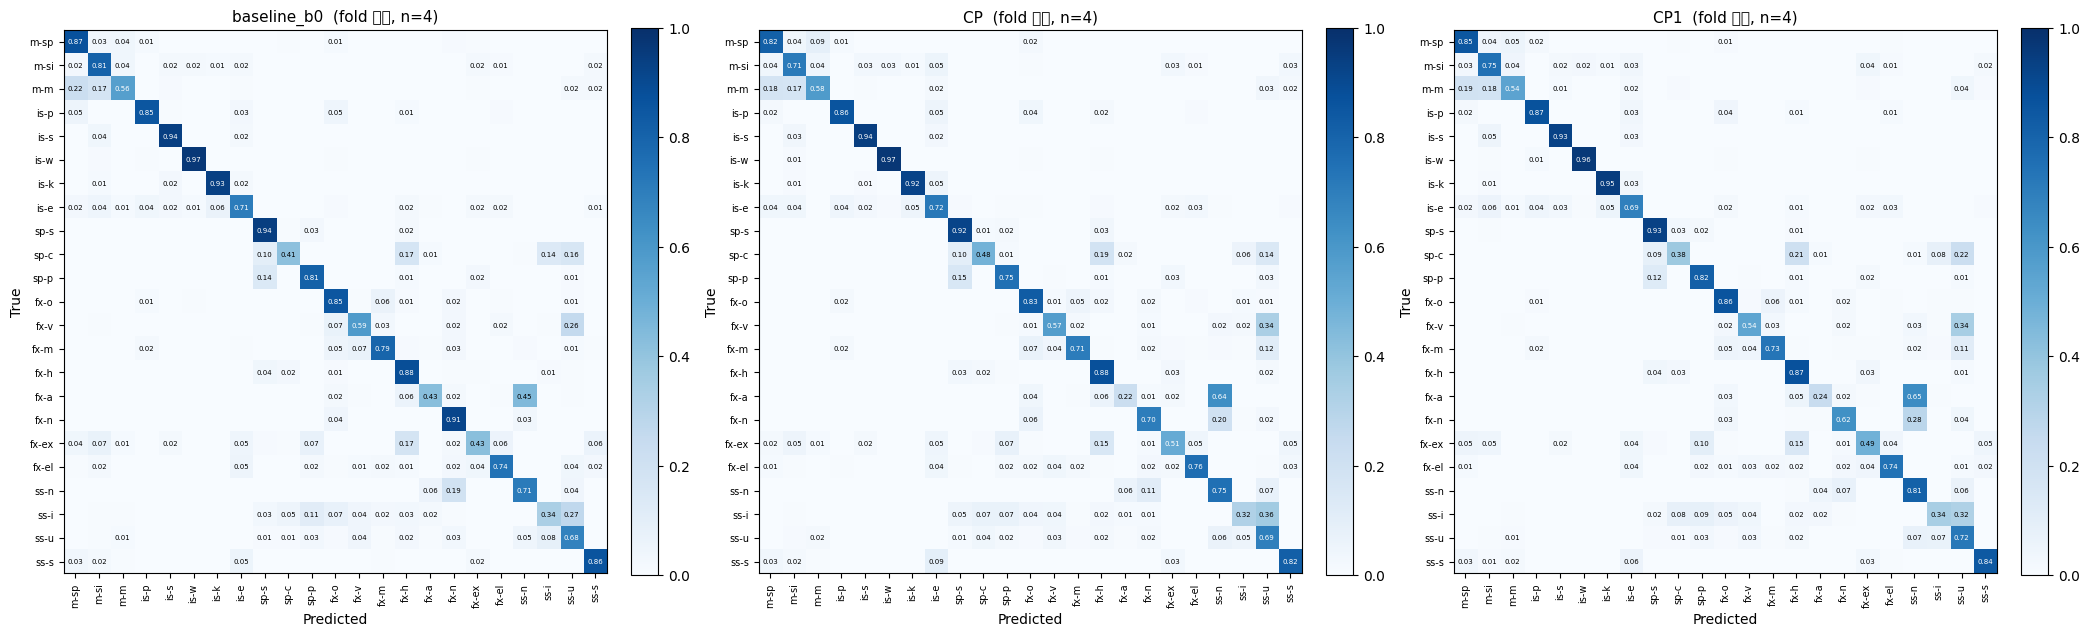

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_602020_pureval\plots\cm_foldavg_3models.png


In [25]:
## 9. fold 평균 confusion matrix (baseline_b0 / CP / CP1)
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

labels = [name for name, _ in sorted(class_dict.items(), key=lambda kv: kv[1])]

def fold_avg_cm(label):
    """각 fold의 row-normalized confusion matrix를 평균."""
    files = sorted(glob.glob(str(OUTPUT_ROOT / label / 'both' / 'fold_*' / 'evaluation' / 'confusion_matrix_normalized_true.csv')))
    if not files:
        return None, 0
    mats = [pd.read_csv(f, index_col=0).reindex(index=labels, columns=labels).fillna(0.0).values for f in files]
    return np.mean(mats, axis=0), len(files)

strategies = ['baseline_b0', 'CP', 'CP1']
data = [(s, *fold_avg_cm(s)) for s in strategies]
data = [(s, m, n) for s, m, n in data if m is not None]

fig, axes = plt.subplots(1, len(data), figsize=(7 * len(data), 6.5))
if len(data) == 1:
    axes = [axes]
for ax, (s, m, n) in zip(axes, data):
    im = ax.imshow(m, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{s}  (fold 평균, n={n})', fontsize=11)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = m[i, j]
            if v >= 0.01:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=5,
                        color='white' if v > 0.5 else 'black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'cm_foldavg_3models.png', dpi=180, bbox_inches='tight')
plt.show()

for s, m, n in data:
    pd.DataFrame(m, index=labels, columns=labels).round(4).to_csv(OUTPUT_ROOT / f'cm_foldavg_{s}.csv')
print('saved:', PLOTS_DIR / 'cm_foldavg_3models.png')


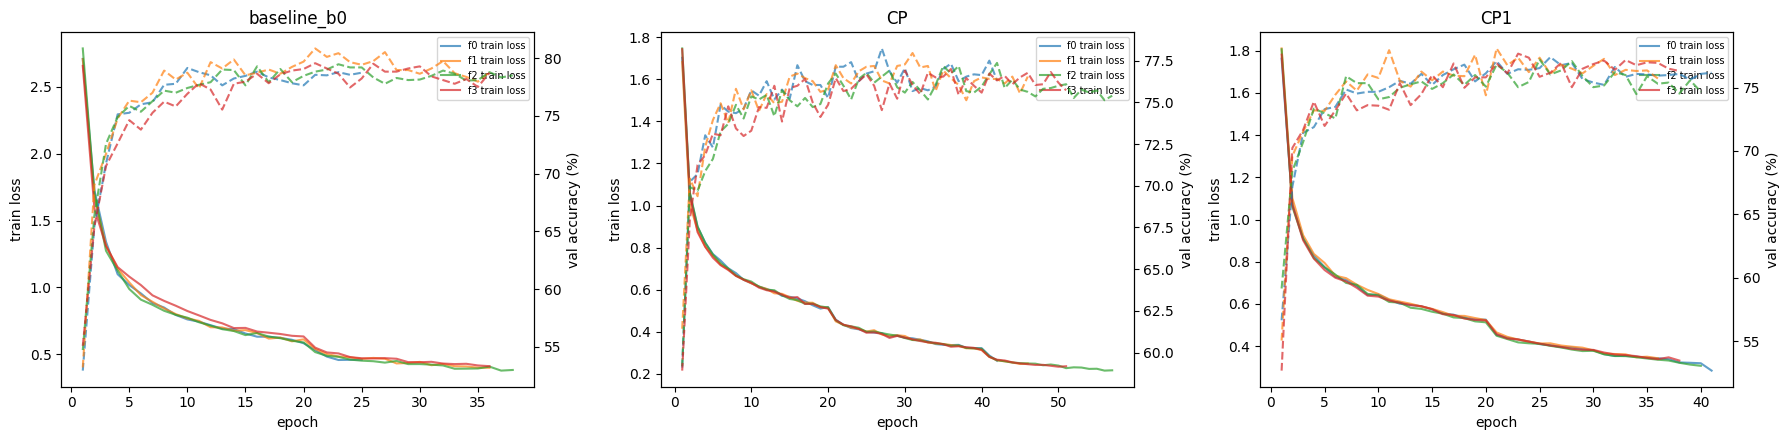

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_602020_pureval\plots\curves_3models.png


In [26]:
## 10. 학습 곡선 (train loss + val accuracy) — 모델별 3개
import json
import glob
from pathlib import Path
import matplotlib.pyplot as plt

strategies = ['baseline_b0', 'CP', 'CP1']
fig, axes = plt.subplots(1, len(strategies), figsize=(6 * len(strategies), 4.5), squeeze=False)
axes = axes[0]

for ax, s in zip(axes, strategies):
    hfiles = sorted(glob.glob(str(OUTPUT_ROOT / s / 'both' / 'fold_*' / 'history.json')))
    if not hfiles:
        ax.set_title(f'{s} (history 없음)'); ax.set_xlabel('epoch'); continue
    ax2 = ax.twinx()
    for hf in hfiles:
        h = json.load(open(hf, encoding='utf-8'))
        fold = Path(hf).parent.name.replace('fold_', 'f')
        tl = h.get('train_total_loss') or h.get('train_cls_loss')
        va = h.get('val_accuracy')
        if tl:
            ax.plot(range(1, len(tl) + 1), tl, alpha=0.7, label=f'{fold} train loss')
        if va:
            ax2.plot(range(1, len(va) + 1), va, '--', alpha=0.7, label=f'{fold} val acc')
    ax.set_title(s); ax.set_xlabel('epoch'); ax.set_ylabel('train loss')
    ax2.set_ylabel('val accuracy (%)')
    ax.legend(fontsize=7, loc='upper right')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'curves_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved:', PLOTS_DIR / 'curves_3models.png')


## 7. per-class recall 변화 (baseline_b0 vs CP vs CP1)

In [24]:
def diag_for(label):
    pat = str(OUTPUT_ROOT / label / 'both' / 'fold_*' / 'evaluation' / 'confusion_matrix_normalized_true.csv')
    files = sorted(glob.glob(pat))
    if not files:
        return None
    mats = []
    for f in files:
        df = pd.read_csv(f, index_col=0)
        mats.append(pd.Series(np.diag(df.values), index=df.index))
    return pd.concat(mats, axis=1).mean(axis=1) * 100

pc = pd.DataFrame()
for lab in ['baseline_b0', 'CP', 'CP1']:
    d = diag_for(lab)
    if d is not None:
        pc[lab] = d.round(2)
if 'baseline_b0' in pc.columns:
    for lab in ['CP', 'CP1']:
        if lab in pc.columns:
            pc[f'{lab}_minus_base'] = (pc[lab] - pc['baseline_b0']).round(2)
    if 'CP_minus_base' in pc.columns:
        pc = pc.sort_values('CP_minus_base')
pc['CP_chosen_thr'] = pc.index.map(ret['CP_chosen_thr']) if 'ret' in dir() else None
pc.to_csv(OUTPUT_ROOT / 'per_class_recall_change.csv')
display(pc)

,baseline_b0,CP,CP1,CP_minus_base,CP1_minus_base,CP_chosen_thr
fx-n,91.48,70.27,62.50,-21.21,-28.98,DROP
fx-a,42.65,22.06,23.53,-20.59,-19.12,DROP
m-si,80.63,71.30,75.18,-9.33,-5.45,DROP
fx-m,79.46,70.54,73.21,-8.92,-6.25,DROP
m-sp,87.23,81.57,85.04,-5.66,-2.19,DROP
sp-p,80.90,75.35,81.94,-5.55,1.04,DROP
ss-s,86.05,81.98,84.30,-4.07,-1.75,ge4
sp-s,94.41,92.08,93.32,-2.33,-1.09,ge3
fx-o,85.27,82.99,86.10,-2.28,0.83,ge4
ss-i,33.54,31.71,34.15,-1.83,0.61,ge2
